In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


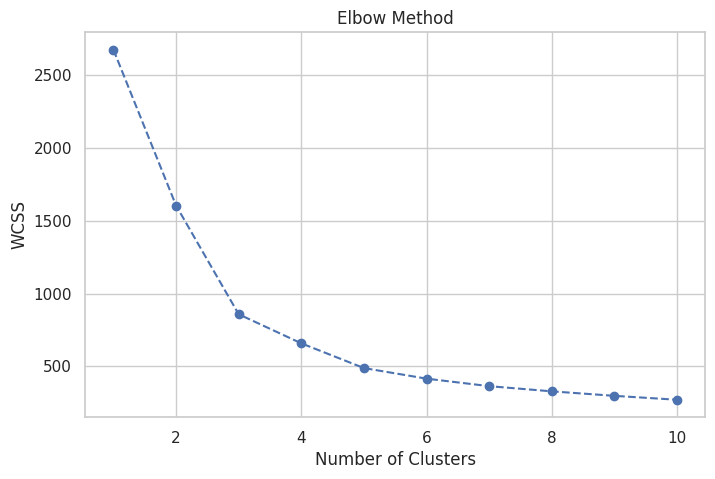

In [ ]:
X = df[['bmi', 'charges']]
X_scaled = StandardScaler().fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

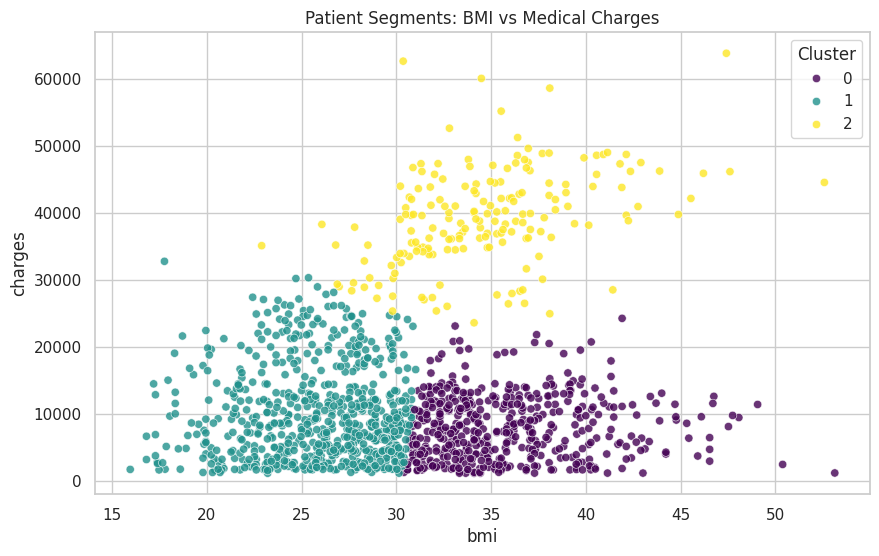

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='Cluster', data=df, palette='viridis', alpha=0.8)
plt.title('Patient Segments: BMI vs Medical Charges')
plt.show()

In [ ]:
# Group by cluster and calculate the average for numerical columns
cluster_profile = df.groupby('Cluster')[['age', 'bmi', 'charges']].mean()

# Count how many smokers are in each cluster
smoker_counts = df.groupby(['Cluster', 'smoker']).size().unstack(fill_value=0)
cluster_profile['smokers_count'] = smoker_counts['yes']
cluster_profile['non_smokers_count'] = smoker_counts['no']

# Display the final profile
print(cluster_profile)

               age        bmi       charges  smokers_count  non_smokers_count
Cluster                                                                      
0        40.354508  35.742295   7958.581554              0                488
1        37.718141  25.832609  10049.818454            115                552
2        41.573770  34.726967  39173.815757            159                 24


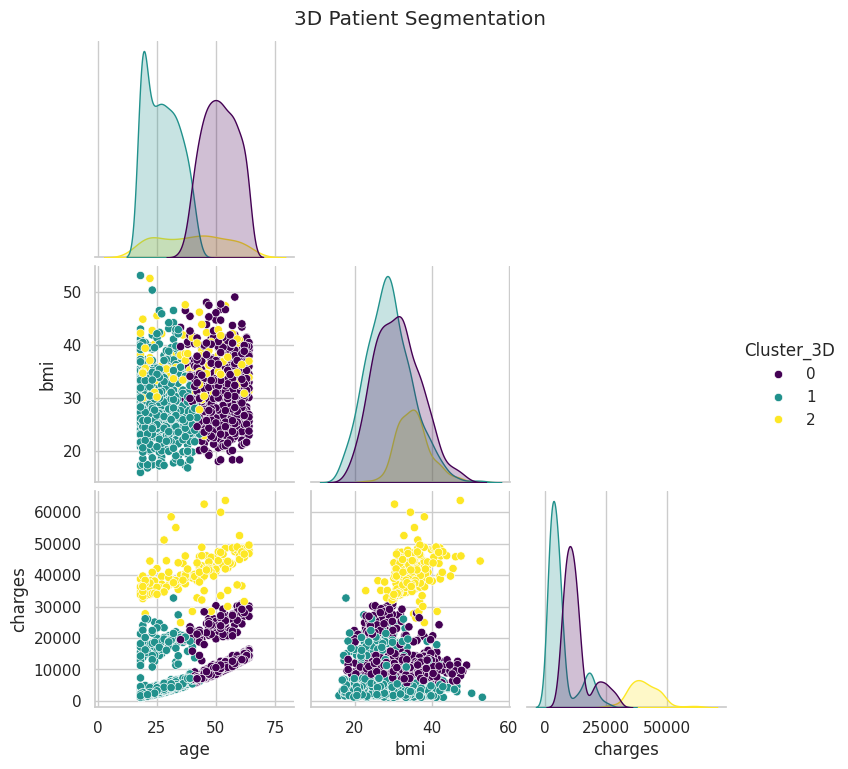

In [9]:
# Select 3 features this time
X_3d = df[['age', 'bmi', 'charges']]
X_scaled_3d = StandardScaler().fit_transform(X_3d)

# Apply K-Means with 3 clusters
kmeans_3d = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['Cluster_3D'] = kmeans_3d.fit_predict(X_scaled_3d)

# Visualize the 3D interaction using a pairplot
sns.pairplot(df, vars=['age', 'bmi', 'charges'], hue='Cluster_3D', palette='viridis', corner=True)
plt.suptitle('3D Patient Segmentation', y=1.02)
plt.show()

Silhouette Score: 0.348


/tmp/ipykernel_801/350774326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_3D', y='charges', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_801/350774326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_3D', y='bmi', data=df, ax=axes[1], palette='viridis')
/tmp/ipykernel_801/350774326.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_3D', y='age', data=df, ax=axes[2], palette='viridis')


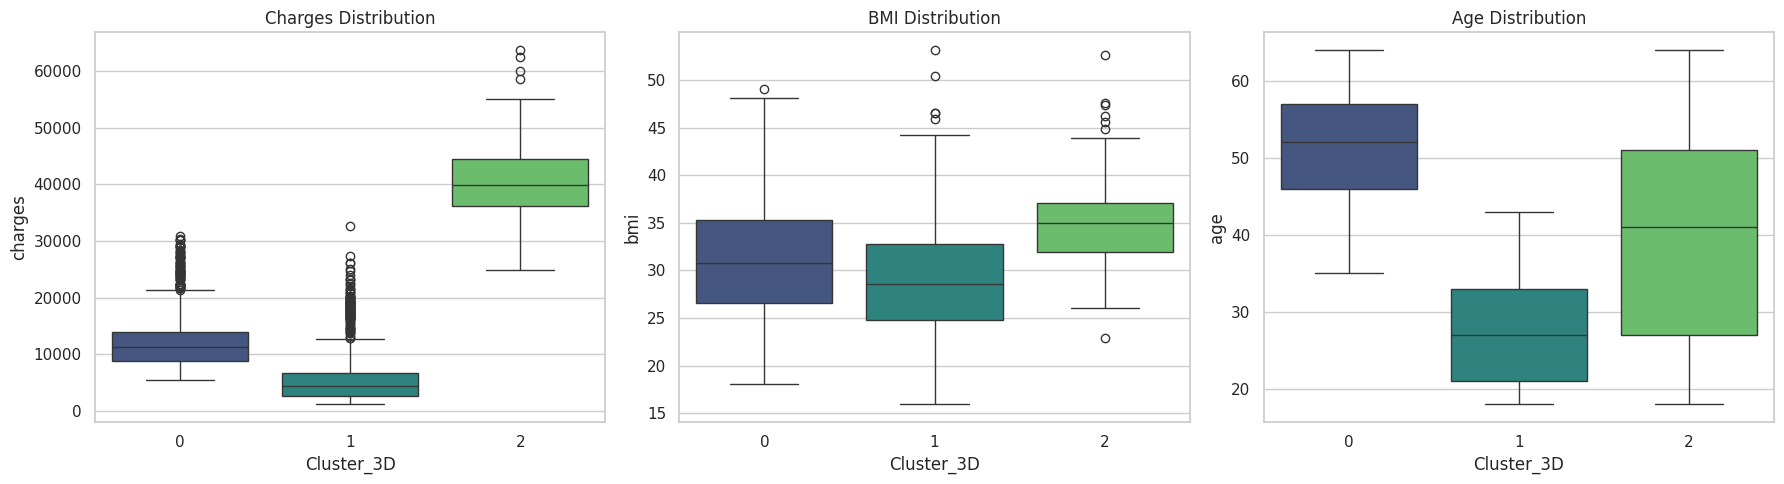

In [10]:
score = silhouette_score(X_scaled_3d, df['Cluster_3D'])
print(f"Silhouette Score: {score:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Cluster_3D', y='charges', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Charges Distribution')

sns.boxplot(x='Cluster_3D', y='bmi', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('BMI Distribution')

sns.boxplot(x='Cluster_3D', y='age', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.show()